In [52]:
import sys
from pathlib import Path
project_root = Path().resolve().parent  
project_root
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [53]:
from importlib import reload

In [54]:
from src import data_broker,calendar_iterator
from src import stock_metrics
from src import stock_plots

In [55]:
import pandas as pd

In [56]:
tickers=['SPY','QQQ','QQQE','IWM','XSW','XLY','XLV','XLU','XLRE','XLP','XLK','XLI','XLF','XLE','XLC','XLB','XBI']#,'VXX']

In [57]:
broker = data_broker.DataBroker(tickers=tickers, start_date="2022-01-01", end_date="2026-04-01")
universe_data = broker.fetch_universe_data()

[*********************100%***********************]  17 of 17 completed


In [58]:
df_prices=universe_data['price']

In [59]:
df_prices.columns

Index(['SPY', 'QQQ', 'QQQE', 'IWM', 'XSW', 'XLY', 'XLV', 'XLU', 'XLRE', 'XLP',
       'XLK', 'XLI', 'XLF', 'XLE', 'XLC', 'XLB', 'XBI'],
      dtype='str')

In [60]:
min_lag=10
large_lag=50

In [61]:
today=df_prices.index[-1]

In [62]:
print(today)
for col in df_prices.columns:    
    h_value=stock_metrics.get_hurst_exponent(df_prices[col],min_lag,large_lag)
    print(f'{col} ..... {round(h_value,3)}')

2026-03-31 00:00:00
SPY ..... 0.544
QQQ ..... 0.552
QQQE ..... 0.567
IWM ..... 0.572
XSW ..... 0.579
XLY ..... 0.586
XLV ..... 0.56
XLU ..... 0.61
XLRE ..... 0.569
XLP ..... 0.587
XLK ..... 0.568
XLI ..... 0.573
XLF ..... 0.599
XLE ..... 0.576
XLC ..... 0.558
XLB ..... 0.569
XBI ..... 0.539


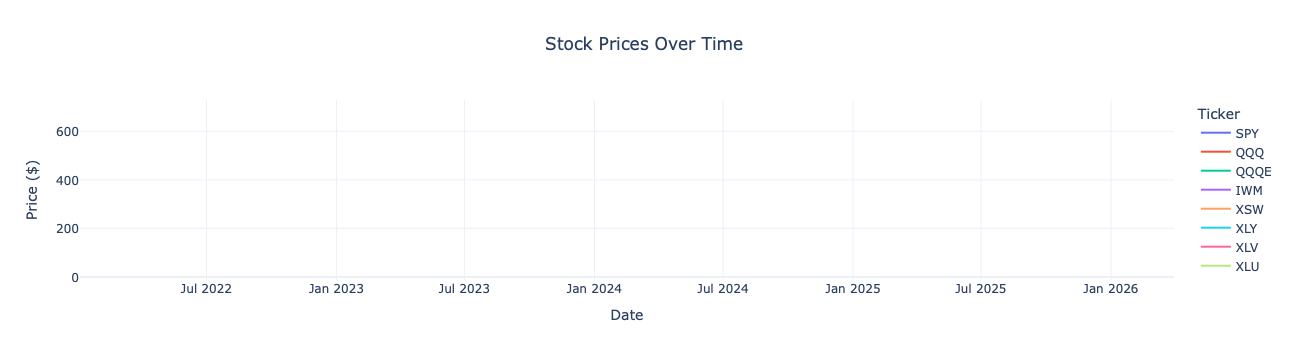

In [23]:
stock_plots.plot_ticker_prices(df_prices)

In [30]:
calendar = calendar_iterator.CalendarIterator(universe_data, interval="ME")

In [48]:
today=pd.to_datetime('2023-10-01')

In [49]:
snapshot=calendar.get_historical_snapshot(today)
df_prices=snapshot['price']

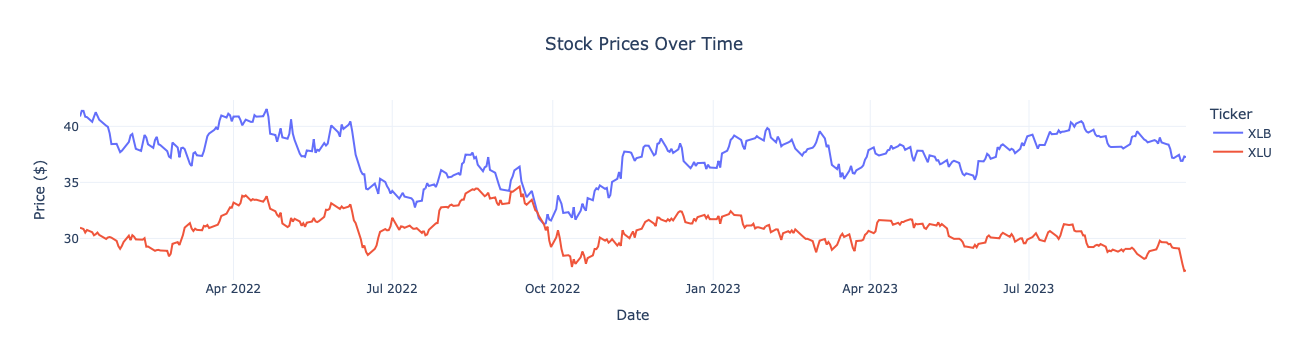

In [50]:
stock_plots.plot_ticker_prices(df_prices[['XLB','XLU']])

In [51]:
print(today)
for col in df_prices.columns:    
    h_value=stock_metrics.get_hurst_exponent(df_prices[col],min_lag,100)
    print(f'{col} ..... {round(h_value,3)}')

2023-10-01 00:00:00
SPY ..... 0.539
QQQ ..... 0.553
QQQE ..... 0.537
IWM ..... 0.569
XSW ..... 0.536
XLY ..... 0.576
XLV ..... 0.61
XLU ..... 0.66
XLRE ..... 0.638
XLP ..... 0.65
XLK ..... 0.547
XLI ..... 0.571
XLF ..... 0.576
XLE ..... 0.567
XLC ..... 0.516
XLB ..... 0.589
XBI ..... 0.584
